In [1]:
!pip install git+https://github.com/borongzhang/magpie_ptychography.git@main


  Cloning https://github.com/borongzhang/magpie_ptychography.git (to revision main) to /private/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/pip-req-build-hlxxrkxy
  Running command git clone --filter=blob:none --quiet https://github.com/borongzhang/magpie_ptychography.git /private/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/pip-req-build-hlxxrkxy
  Resolved https://github.com/borongzhang/magpie_ptychography.git to commit 77807f6f28555c9a465728127b2bc29ec069093a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import h5py
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import imageio.v2 as imageio
import random
import time
from magpie_ptychography.src import magpie_loop, rpie, lbfgs
from magpie_ptychography import feasibility_distance_misfit
from magpie_ptychography import generate_intensity_measurements, generate_scanning_positions


ModuleNotFoundError: No module named 'magpie_ptychography'

In [2]:
!pip install -e .


Obtaining file:///Users/borongzhang/Desktop/ptycho_submission/magpie_ptychography
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for magpie-ptychography (pyproject.toml) ... done
  Created wheel for magpie-ptychography: filename=magpie_ptychography-0.1.0-0.editable-py3-none-any.whl size=4380 sha256=3d3bf040e2f9030f48edacbb293654f0cf47357f2eea1638150f150466f10e04
  Stored in directory: /private/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/pip-ephem-wheel-cache-zccx9xbt/wheels/84/cc/47/95448624dea9e69459a336ce7379af0c656d81f1a0d3039233
Successfully built magpie-ptychography
  Attempting uninstall: magpie-ptychography
    Found existing installation: magpie-ptychography 0.1.0
    Uninstalling magpie-ptychography-0.1.0:
      Successfully uninstalled magpie-ptychography-0.1.0


# Setup

In [4]:
# Size of the object
object_shape = (512, 512)

# Side length of the probe
n_probe = 128

# Probe shift for intensity measurement
shift = 64


## Realistic Synthetic Object and Probe

In [5]:
mat_data = scipy.io.loadmat('assets/recon_zoneplate_Yi.mat')
obj = mat_data['obj']
orgn_probe = mat_data['probe']

pad_x = (object_shape[0] - obj.shape[0]) // 2
pad_y = (object_shape[1] - obj.shape[1]) // 2

# Pad the object to the desired shape
real_object = np.pad(obj, ((pad_x, pad_x), (pad_y, pad_y)), mode='edge')

ratio = orgn_probe.shape[0] // n_probe

real_probe = orgn_probe[::ratio,::ratio]

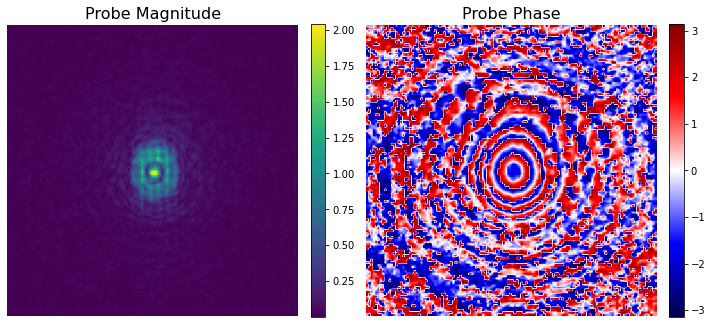

In [6]:
# Compute magnitude and phase
magnitude = np.abs(real_probe)
phase = np.angle(real_probe)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Probe Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='seismic')
ax.set_title('Probe Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('probe_mag_phase.png', dpi=120, bbox_inches='tight')
plt.show()

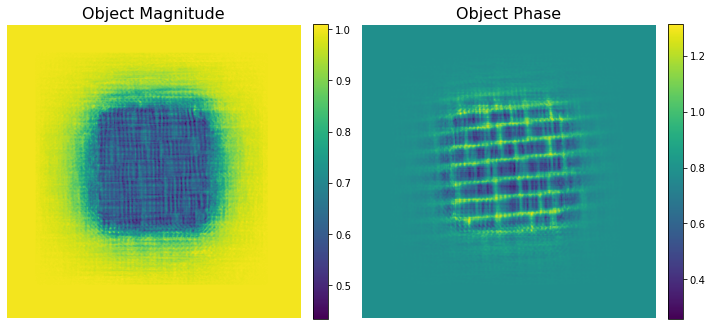

In [7]:
magnitude = np.abs(real_object)
phase = np.angle(real_object)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Object Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='viridis')
ax.set_title('Object Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('realistic_object.png', dpi=120, bbox_inches='tight')
plt.show()

## Test Synthetic Object 

In [8]:
# Load the images
baboon_image = imageio.imread('assets/baboon.tiff')
# Convert the Baboon image to grayscale 
if baboon_image.ndim == 3:
    baboon_image = np.mean(baboon_image, axis=2)
    
cameraman_image = imageio.imread('assets/cameraman.tif')
if cameraman_image.ndim == 3:
    cameraman_image = np.mean(cameraman_image, axis=2)

# Normalize the Baboon image to [0, 1] for magnitude
baboon_magnitude = baboon_image / np.max(baboon_image)

# Normalize the Cameraman image to [0, pi/2] for phase
cameraman_phase = (cameraman_image / np.max(cameraman_image)) * (np.pi / 2)

synthetic_object = baboon_magnitude * np.exp(1j * cameraman_phase)


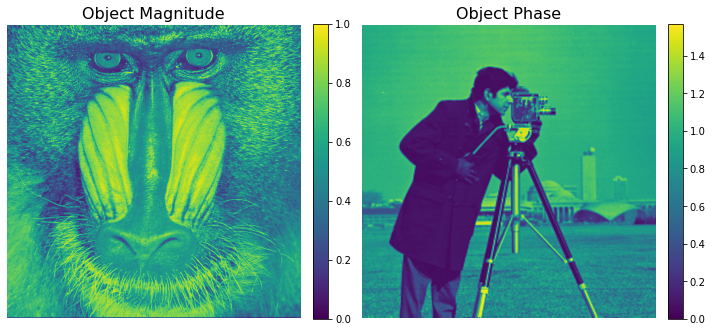

In [9]:
magnitude = np.abs(synthetic_object)
phase = np.angle(synthetic_object)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Object Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='viridis')
ax.set_title('Object Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('synthetic_object.png', dpi=120, bbox_inches='tight')
plt.show()


## Data Generation

In [10]:
# Choose Object
probe = real_probe
ground_truth = synthetic_object

# Noise added to the measurement
noise_level = 0.05

# Define scanning positions
pos_array = synthetic.generate_scanning_positions(object_shape, n_probe, shift)

# Generate the data
data = synthetic.generate_intensity_measurements(ground_truth, probe, pos_array, noise_level)


## Misfits

In [12]:
misfit = misfits.feasibility_distance_misfit

# Algorithms

## rPIE

## MAGPIE

## L-BFGS

# Numerical examples

In [45]:
z_initial = np.ones_like(ground_truth)
num_iterations = 1000
alpha_rpie = 0.01

s = time.time()
z_recon_rPIE, res_rPIE, errors_rPIE = algorithms.rpie(z_initial, probe, data, pos_array, 
                                                num_iterations, misfit, ground_truth,
                                                alpha = alpha_rpie, metric = True, tol = 1e-4)
print(time.time()-s)

Iteration: 0, f: 1649.3349118262915, g: 0.059521583362859266, error: 242.3473661616201
Iteration: 1, f: 74.94741440313156, g: 0.005212317608407445, error: 213.3695387993071
Iteration: 2, f: 38.82533317002912, g: 0.0019131486429007554, error: 204.56311420758766
Iteration: 3, f: 28.711053710756143, g: 0.0011429034546941296, error: 198.54483293188198


KeyboardInterrupt: 

In [46]:
z_initial = np.ones_like(ground_truth)
num_iterations = 1000
alpha_rpie = 0.01
max_level = int(np.log2(probe.shape[0]))

s = time.time()
z_recon_MAGPIE, res_MAGPIE, errors_MAGPIE = algorithms.magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = max_level)
print(time.time()-s)

Iteration: 0, f: 1649.3349118262915, g: 0.059521583362859266, error: 242.3473661616201
Iteration: 1, f: 23.67250440849838, g: 0.003393601284235525, error: 145.85940050441226
Iteration: 2, f: 11.88980776445007, g: 0.0013094790361616922, error: 132.5145240808064
Iteration: 3, f: 8.420429582047573, g: 0.0009322582133726765, error: 123.16245900735021


KeyboardInterrupt: 

In [47]:
z_initial = np.ones_like(ground_truth)
num_iterations = 1000
alpha_rpie = 0.01

s = time.time()
z_recon_MAGPIE, res_MAGPIE, errors_MAGPIE = algorithms.magpie_recursion(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4)
print(time.time()-s)

Iteration: 0, f: 1649.3349118262915, g: 0.059521583362859266, error: 242.3473661616201
Iteration: 1, f: 24.285234060831996, g: 0.0035482413108831145, error: 145.7657591511774
Iteration: 2, f: 11.880011242639965, g: 0.0012968563314937724, error: 132.46392063477163
Iteration: 3, f: 8.408645145061707, g: 0.0009151081620889373, error: 123.11614687193229


KeyboardInterrupt: 

In [54]:
importlib.reload(algorithms)

<module 'algorithms' from '/Users/borongzhang/Desktop/ptycho_submission/magpie_ptychography/MAGPIE_2024/src/algorithms.py'>

In [55]:

s = time.time()
z_initial = np.ones_like(ground_truth)
zstar, error_f_LBFGS, eval_history_LBFGS = algorithms.lbfgs(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth, tol = 1e-4)
print(time.time()-s)

Iter 1, f = 783.4709713857, g = 0.04575908813990894, Func Evals = 2, Error = 234.4994385893645
Iter 2, f = 289.9514934291461, g = 0.016263256780714316, Func Evals = 3, Error = 232.76494727736363
Iter 3, f = 187.50462707709883, g = 0.009016363980851956, Func Evals = 4, Error = 231.4534072671709
Iter 4, f = 136.6470504791126, g = 0.006955580487756022, Func Evals = 5, Error = 229.85174122984301
Iter 5, f = 100.03210442124053, g = 0.006070208914253817, Func Evals = 6, Error = 227.36543838385143
Iter 6, f = 84.30828087989049, g = 0.004922429896882945, Func Evals = 7, Error = 225.5770800824636
Iter 7, f = 75.57078955754473, g = 0.002996092183827418, Func Evals = 8, Error = 224.8869546214545
Iter 8, f = 65.50401946275434, g = 0.0026374963351805994, Func Evals = 9, Error = 222.9949788584371
Iter 9, f = 58.42225600287305, g = 0.002835128396155517, Func Evals = 10, Error = 221.01512579519735
Iter 10, f = 51.76451387464265, g = 0.002681267757905623, Func Evals = 11, Error = 218.67136479644174
Ite

KeyboardInterrupt: 

In [56]:
res_f_LBFGS = eval_history_LBFGS['f']
errors_LBFGS = eval_history_LBFGS['error']

NameError: name 'eval_history_LBFGS' is not defined

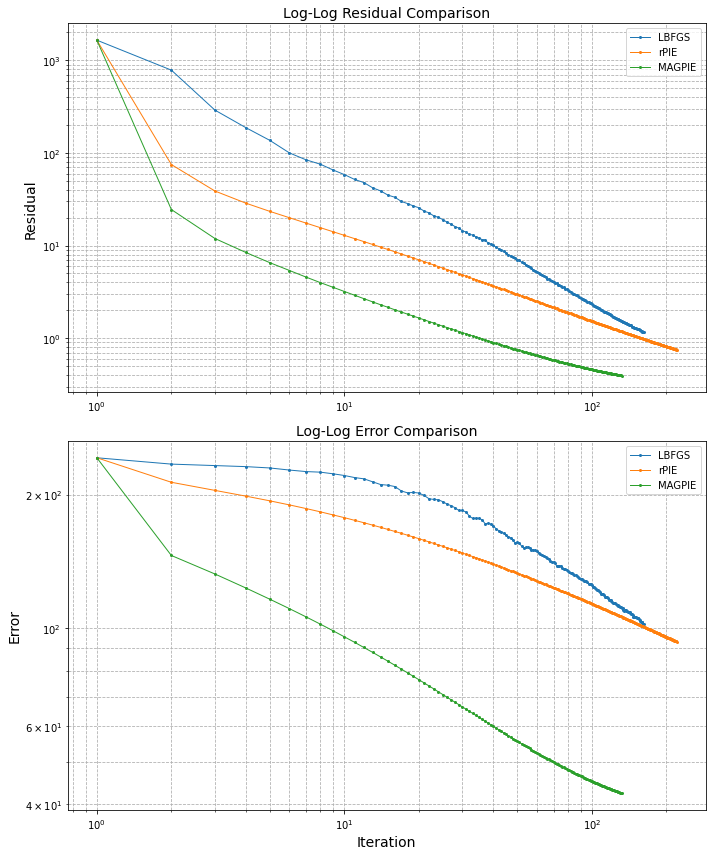

In [21]:
# Create a figure with 2 rows and 1 column of subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# --- Plot on the top subplot (Residuals) ---
ax1.plot(np.arange(1, len(res_f_LBFGS)+1), res_f_LBFGS, label='LBFGS', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_rPIE)+1), res_rPIE, label='rPIE', linestyle='-', marker='o', linewidth=1, markersize=2)
ax1.plot(np.arange(1, len(res_MAGPIE)+1), res_MAGPIE, label='MAGPIE', linestyle='-', marker='o', linewidth=1, markersize=2)
#ax1.set_xlabel('Iteration', fontsize=18)
ax1.set_ylabel('Residual', fontsize=14)
ax1.set_title('Log-Log Residual Comparison', fontsize=14)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, which="both", ls="--")

# --- Plot on the bottom subplot (Errors) ---
ax2.plot(np.arange(1, len(errors_LBFGS)+1), errors_LBFGS, label='LBFGS', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_rPIE)+1), errors_rPIE, label='rPIE', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.plot(np.arange(1, len(errors_MAGPIE)+1), errors_MAGPIE, label='MAGPIE', linestyle='-', marker='o', linewidth=1, markersize=2)
ax2.set_xlabel('Iteration', fontsize=14)
ax2.set_ylabel('Error', fontsize=14)
ax2.set_title('Log-Log Error Comparison', fontsize=14)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, which="both", ls="--")
#plt.savefig('metric.png', dpi=200, bbox_inches='tight')

plt.tight_layout()
plt.show()



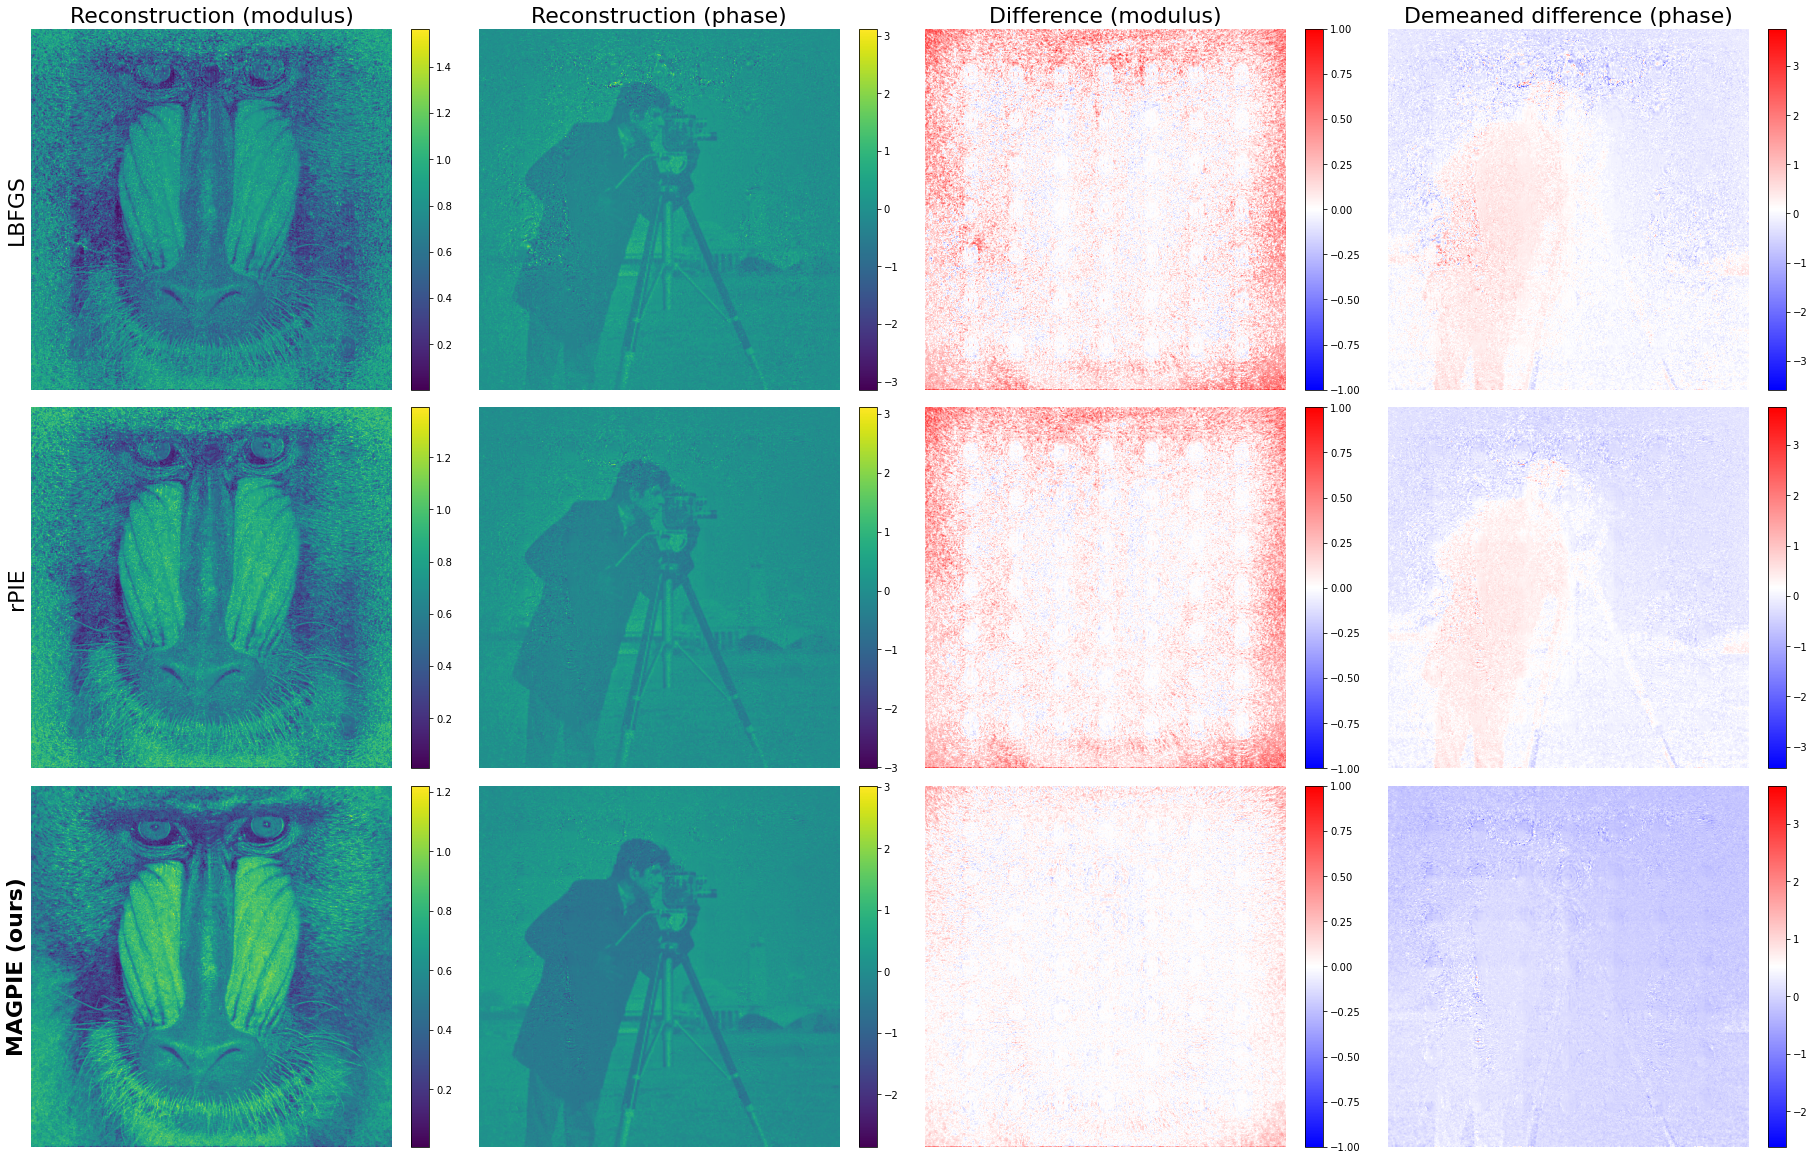

In [22]:
size = object_shape
rPIE_image = z_recon_rPIE
MAGPIE_image = z_recon_MAGPIE
LBFGS_image = zstar.view(np.complex128).reshape(object_shape)
ground_truth = ground_truth

intensity_ground_truth = np.abs(ground_truth)
phase_ground_truth = np.angle(ground_truth)

def calculate_difference(image, ground_truth):
    intensity_diff = np.abs(image) - intensity_ground_truth
    phase_diff = np.angle(image) - phase_ground_truth - np.mean(np.angle(image) - phase_ground_truth)
    return intensity_diff, phase_diff

intensity_LBFGS, phase_LBFGS = np.abs(LBFGS_image), np.angle(LBFGS_image)
intensity_rPIE, phase_rPIE = np.abs(rPIE_image), np.angle(rPIE_image)
intensity_MAGPIE, phase_MAGPIE = np.abs(MAGPIE_image), np.angle(MAGPIE_image)

# Calculate differences
intensity_diff_LBFGS, phase_diff_LBFGS = calculate_difference(LBFGS_image, ground_truth)
intensity_diff_rPIE, phase_diff_rPIE = calculate_difference(rPIE_image, ground_truth)
intensity_diff_MAGPIE, phase_diff_MAGPIE = calculate_difference(MAGPIE_image, ground_truth)

# Updated column titles and row labels
column_titles = [
    "Reconstruction (modulus)", 
    "Reconstruction (phase)", 
    "Difference (modulus)", 
    "Demeaned difference (phase)"
]
row_labels = ["LBFGS", "rPIE", "MAGPIE (ours)"]

# Prepare data for plotting: each tuple contains (intensity, phase, intensity_diff, phase_diff)
image_data = [
    (intensity_LBFGS, phase_LBFGS, intensity_diff_LBFGS, phase_diff_LBFGS),
    (intensity_rPIE, phase_rPIE, intensity_diff_rPIE, phase_diff_rPIE),
    (intensity_MAGPIE, phase_MAGPIE, intensity_diff_MAGPIE, phase_diff_MAGPIE),
]

# Create a new figure using subplots 
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(25, 16), constrained_layout=True)

# Set column titles on the first row.
for j, title in enumerate(column_titles):
    axes[0, j].set_title(title, fontsize=22)

# Loop over each row of image data.
for i, (intensity, phase, intensity_diff, phase_diff) in enumerate(image_data):
    # Set the row label for the first column.
    if i == 2:
        axes[i, 0].set_ylabel(row_labels[i], fontsize=22, fontweight='bold')
    else:
        axes[i, 0].set_ylabel(row_labels[i], fontsize=22)

    # Remove spines and ticks for clarity.
    for j in range(4):
        ax = axes[i, j]
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

    # Plot the intensity image.
    im0 = axes[i, 0].imshow(intensity, cmap='viridis')
    fig.colorbar(im0, ax=axes[i, 0])

    # Plot the phase image.
    im1 = axes[i, 1].imshow(phase, cmap='viridis')
    fig.colorbar(im1, ax=axes[i, 1])
    
    # Plot the intensity difference image with symmetric scaling.
    max_intensity_diff = np.max(np.abs(intensity_diff))
    im2 = axes[i, 2].imshow(intensity_diff, cmap='bwr', vmin=-1, vmax=1)
    fig.colorbar(im2, ax=axes[i, 2])

    # Plot the phase difference image with symmetric scaling.
    max_phase_diff = np.max(np.abs(phase_diff))
    im3 = axes[i, 3].imshow(phase_diff, cmap='bwr')
    fig.colorbar(im3, ax=axes[i, 3])

#plt.savefig('reconstruction.png', dpi=60, bbox_inches='tight')
plt.show()